In [1]:
import pandas as pd

df = pd.read_csv("clean_movies.csv")

### Note: All of the dataset is already cleaned

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


## Movies In Each Genres

In [2]:
df["genres"].value_counts()

genres
Comedy|Drama|Romance                  147
Drama                                 141
Comedy                                138
Comedy|Drama                          138
Comedy|Romance                        131
                                     ... 
Adventure|Horror|Sci-Fi                 1
Crime|Documentary                       1
Comedy|Crime|Drama|Horror|Thriller      1
Comedy|Documentary|Drama                1
Comedy|Crime|Horror                     1
Name: count, Length: 745, dtype: int64

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


## Top 15 Genres

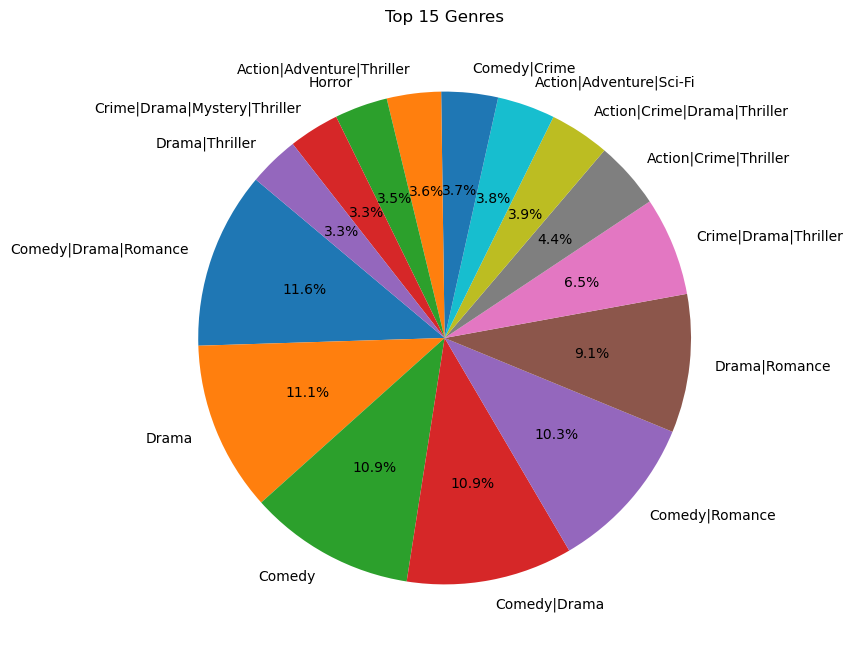

In [18]:
import matplotlib.pyplot as plt

# Get top 15 genres
top_genres = df["genres"].value_counts().head(15)

# Create pie chart
plt.figure(figsize=(8,8))
plt.pie(
    top_genres.values, 
    labels=top_genres.index, 
    autopct="%1.1f%%",   # show percentages
    startangle=140       # rotate for better layout
)
plt.title("Top 15 Genres")
plt.show()


###### Comedy|Drama|Romance Movies Dominate in here

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


### Movie release each year graph

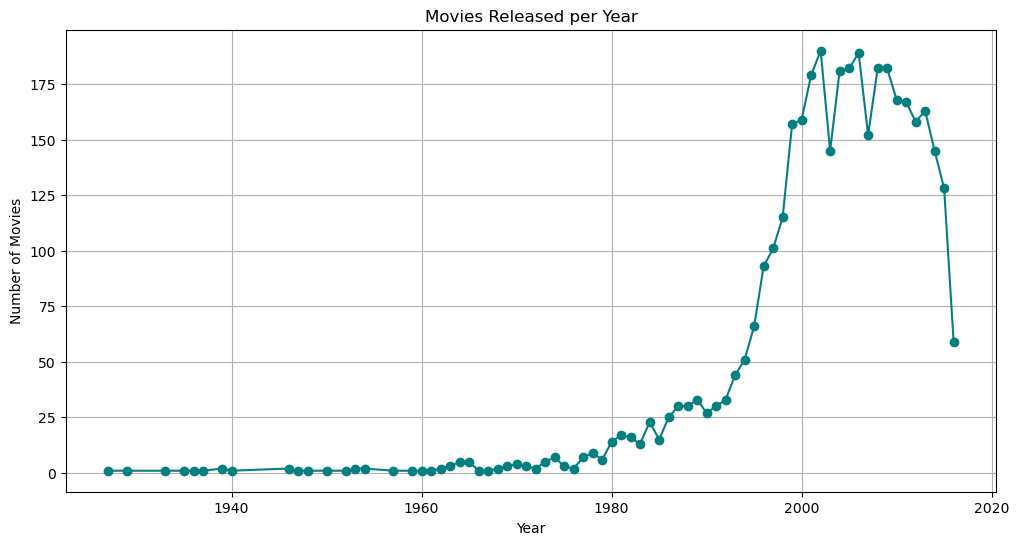

In [8]:
year_counts = df["title_year"].value_counts().sort_index()

plt.figure(figsize=(12,6))
year_counts.plot(kind="line", marker="o", color="teal")
plt.title("Movies Released per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.grid(True)
plt.show()


##### After 2000's year it achived it's peak and in pandamic the movie releases drops significantly

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


### Average Duration by Genre

C:\Users\Harshal\AppData\Local\Temp\ipykernel_27968\1040624005.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_genres.index, y=top10_genres.values, palette="viridis")


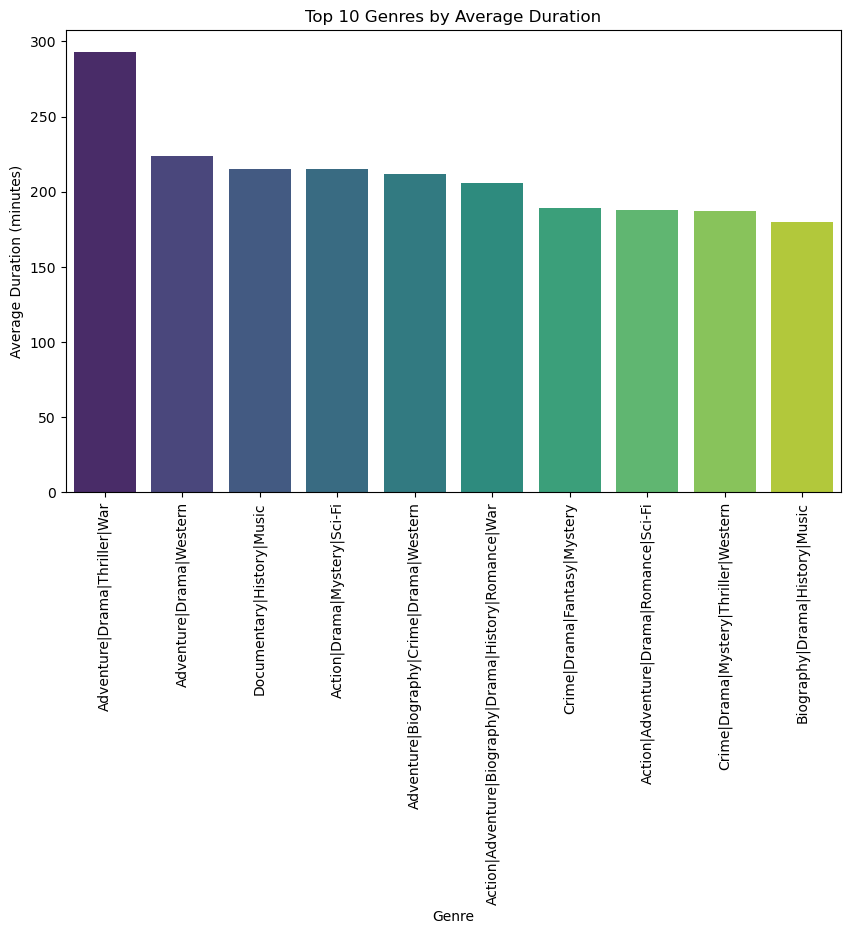

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute average duration per genre
avg_duration = df.groupby("genres")["duration"].mean().sort_values(ascending=False)

# Take top 10 genres
top10_genres = avg_duration.head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=top10_genres.index, y=top10_genres.values, palette="viridis")
plt.xticks(rotation=90)
plt.title("Top 10 Genres by Average Duration")
plt.ylabel("Average Duration (minutes)")
plt.xlabel("Genre")
plt.show()


##### Adventure|Drama|Thriller|War has higher average duration

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


### Budget distribution

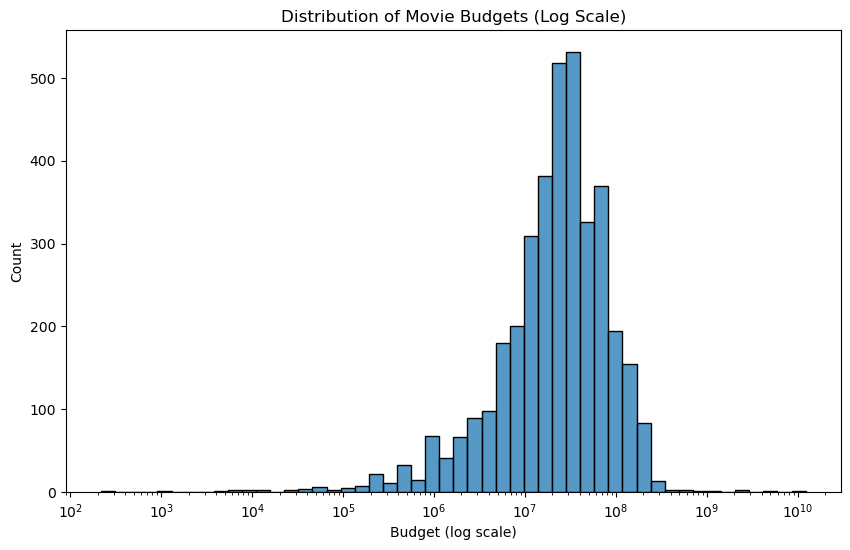

In [12]:
import numpy as np

plt.figure(figsize=(10,6))
sns.histplot(df["budget"], bins=50, log_scale=True)
plt.title("Distribution of Movie Budgets (Log Scale)")
plt.xlabel("Budget (log scale)")
plt.show()


##### Majority movie falls near 10⁷ 

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


### Revenue vs IMDb rating

Task was destroyed but it is pending!
task: <Task pending name='Task-332' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Harshal\AppData\Roaming\Python\Python313\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-333' coro=<Kernel.shell_main() running at C:\Users\Harshal\AppData\Roaming\Python\Python313\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Harshal\AppData\Roaming\Python\Python313\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\ProgramData\anaconda3\Lib\site-packages\matplotlib\transforms.py:109: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def __init__(self, shorthand_name=None):
Task was destroyed but it is pending!
task: <Task pending name='Task-333' coro=<Kernel.shell_main() running at C:\Users\Harshal\AppData\Roaming\Python\Python313\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


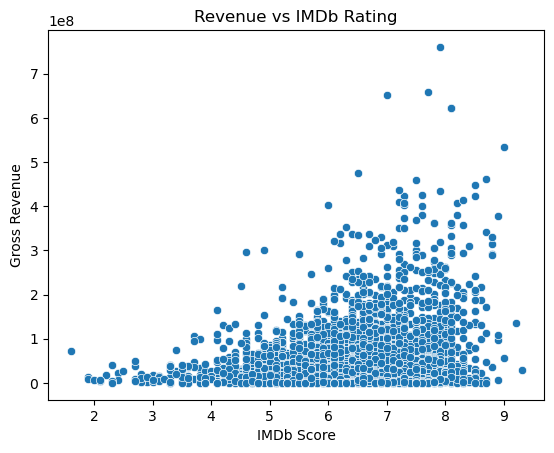

In [26]:
sns.scatterplot(x="imdb_score", y="gross", data=df)
plt.xlabel("IMDb Score")
plt.ylabel("Gross Revenue")
plt.title("Revenue vs IMDb Rating")
plt.show()

##### IMDb score affect revenue

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


### IMDb score distribution

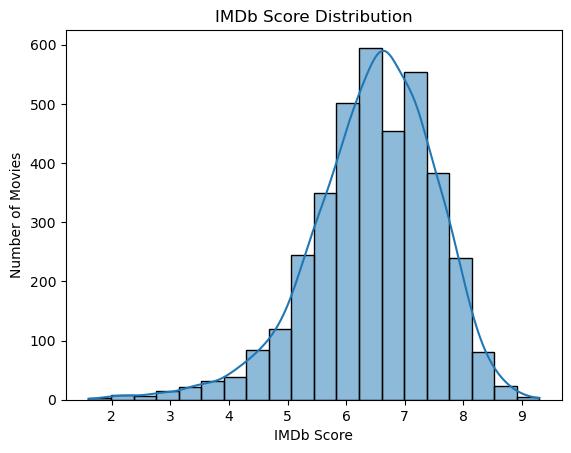

In [19]:
sns.histplot(df["imdb_score"], bins=20, kde=True)
plt.title("IMDb Score Distribution")
plt.xlabel("IMDb Score")
plt.ylabel("Number of Movies")
plt.show()


##### Majority of the movies have score of 5.5 to 7.5

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


### Budget vs IMDb score

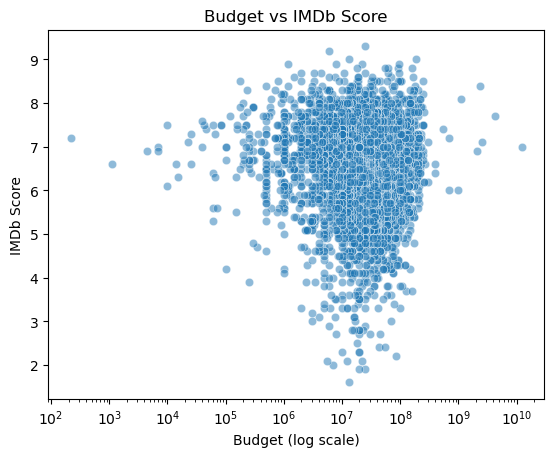

In [20]:
sns.scatterplot(x="budget", y="imdb_score", data=df, alpha=0.5)
plt.xscale("log")  # compress huge budgets
plt.title("Budget vs IMDb Score")
plt.xlabel("Budget (log scale)")
plt.ylabel("IMDb Score")
plt.show()


##### There are very few outlires

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


### Gross vs IMDb

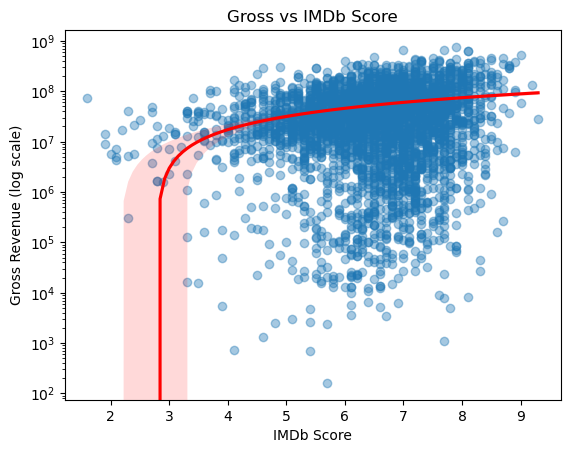

In [25]:
sns.regplot(x="imdb_score", y="gross", data=df,
            scatter_kws={"alpha":0.4}, line_kws={"color":"red"})
plt.yscale("log")
plt.title("Gross vs IMDb Score")
plt.xlabel("IMDb Score")
plt.ylabel("Gross Revenue (log scale)")
plt.show()


##### It shows the momentum of red line curve

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


### Numeric data

In [26]:
selected_columns = [
    "budget", "gross", "duration", "imdb_score",
    "num_voted_users", "num_user_for_reviews",
    "num_critic_for_reviews", "movie_facebook_likes"
]


### Heatmap

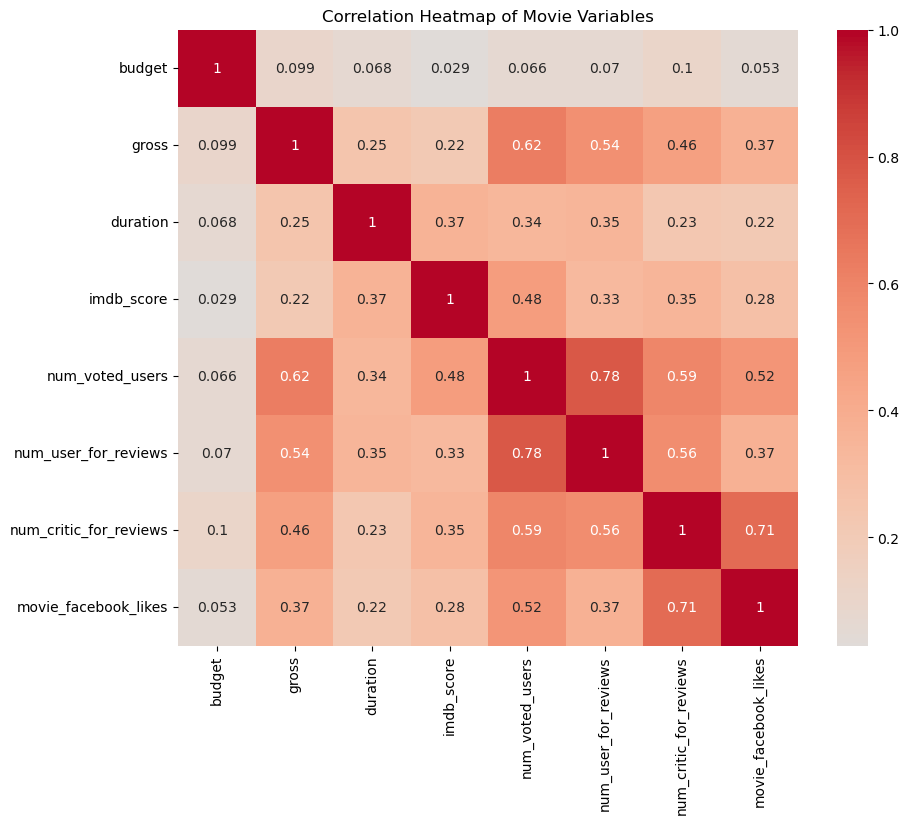

In [27]:
corr = df[selected_columns].corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Movie Variables")
plt.show()


##### Shows the correlation of various numeric data

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


### Pairplot

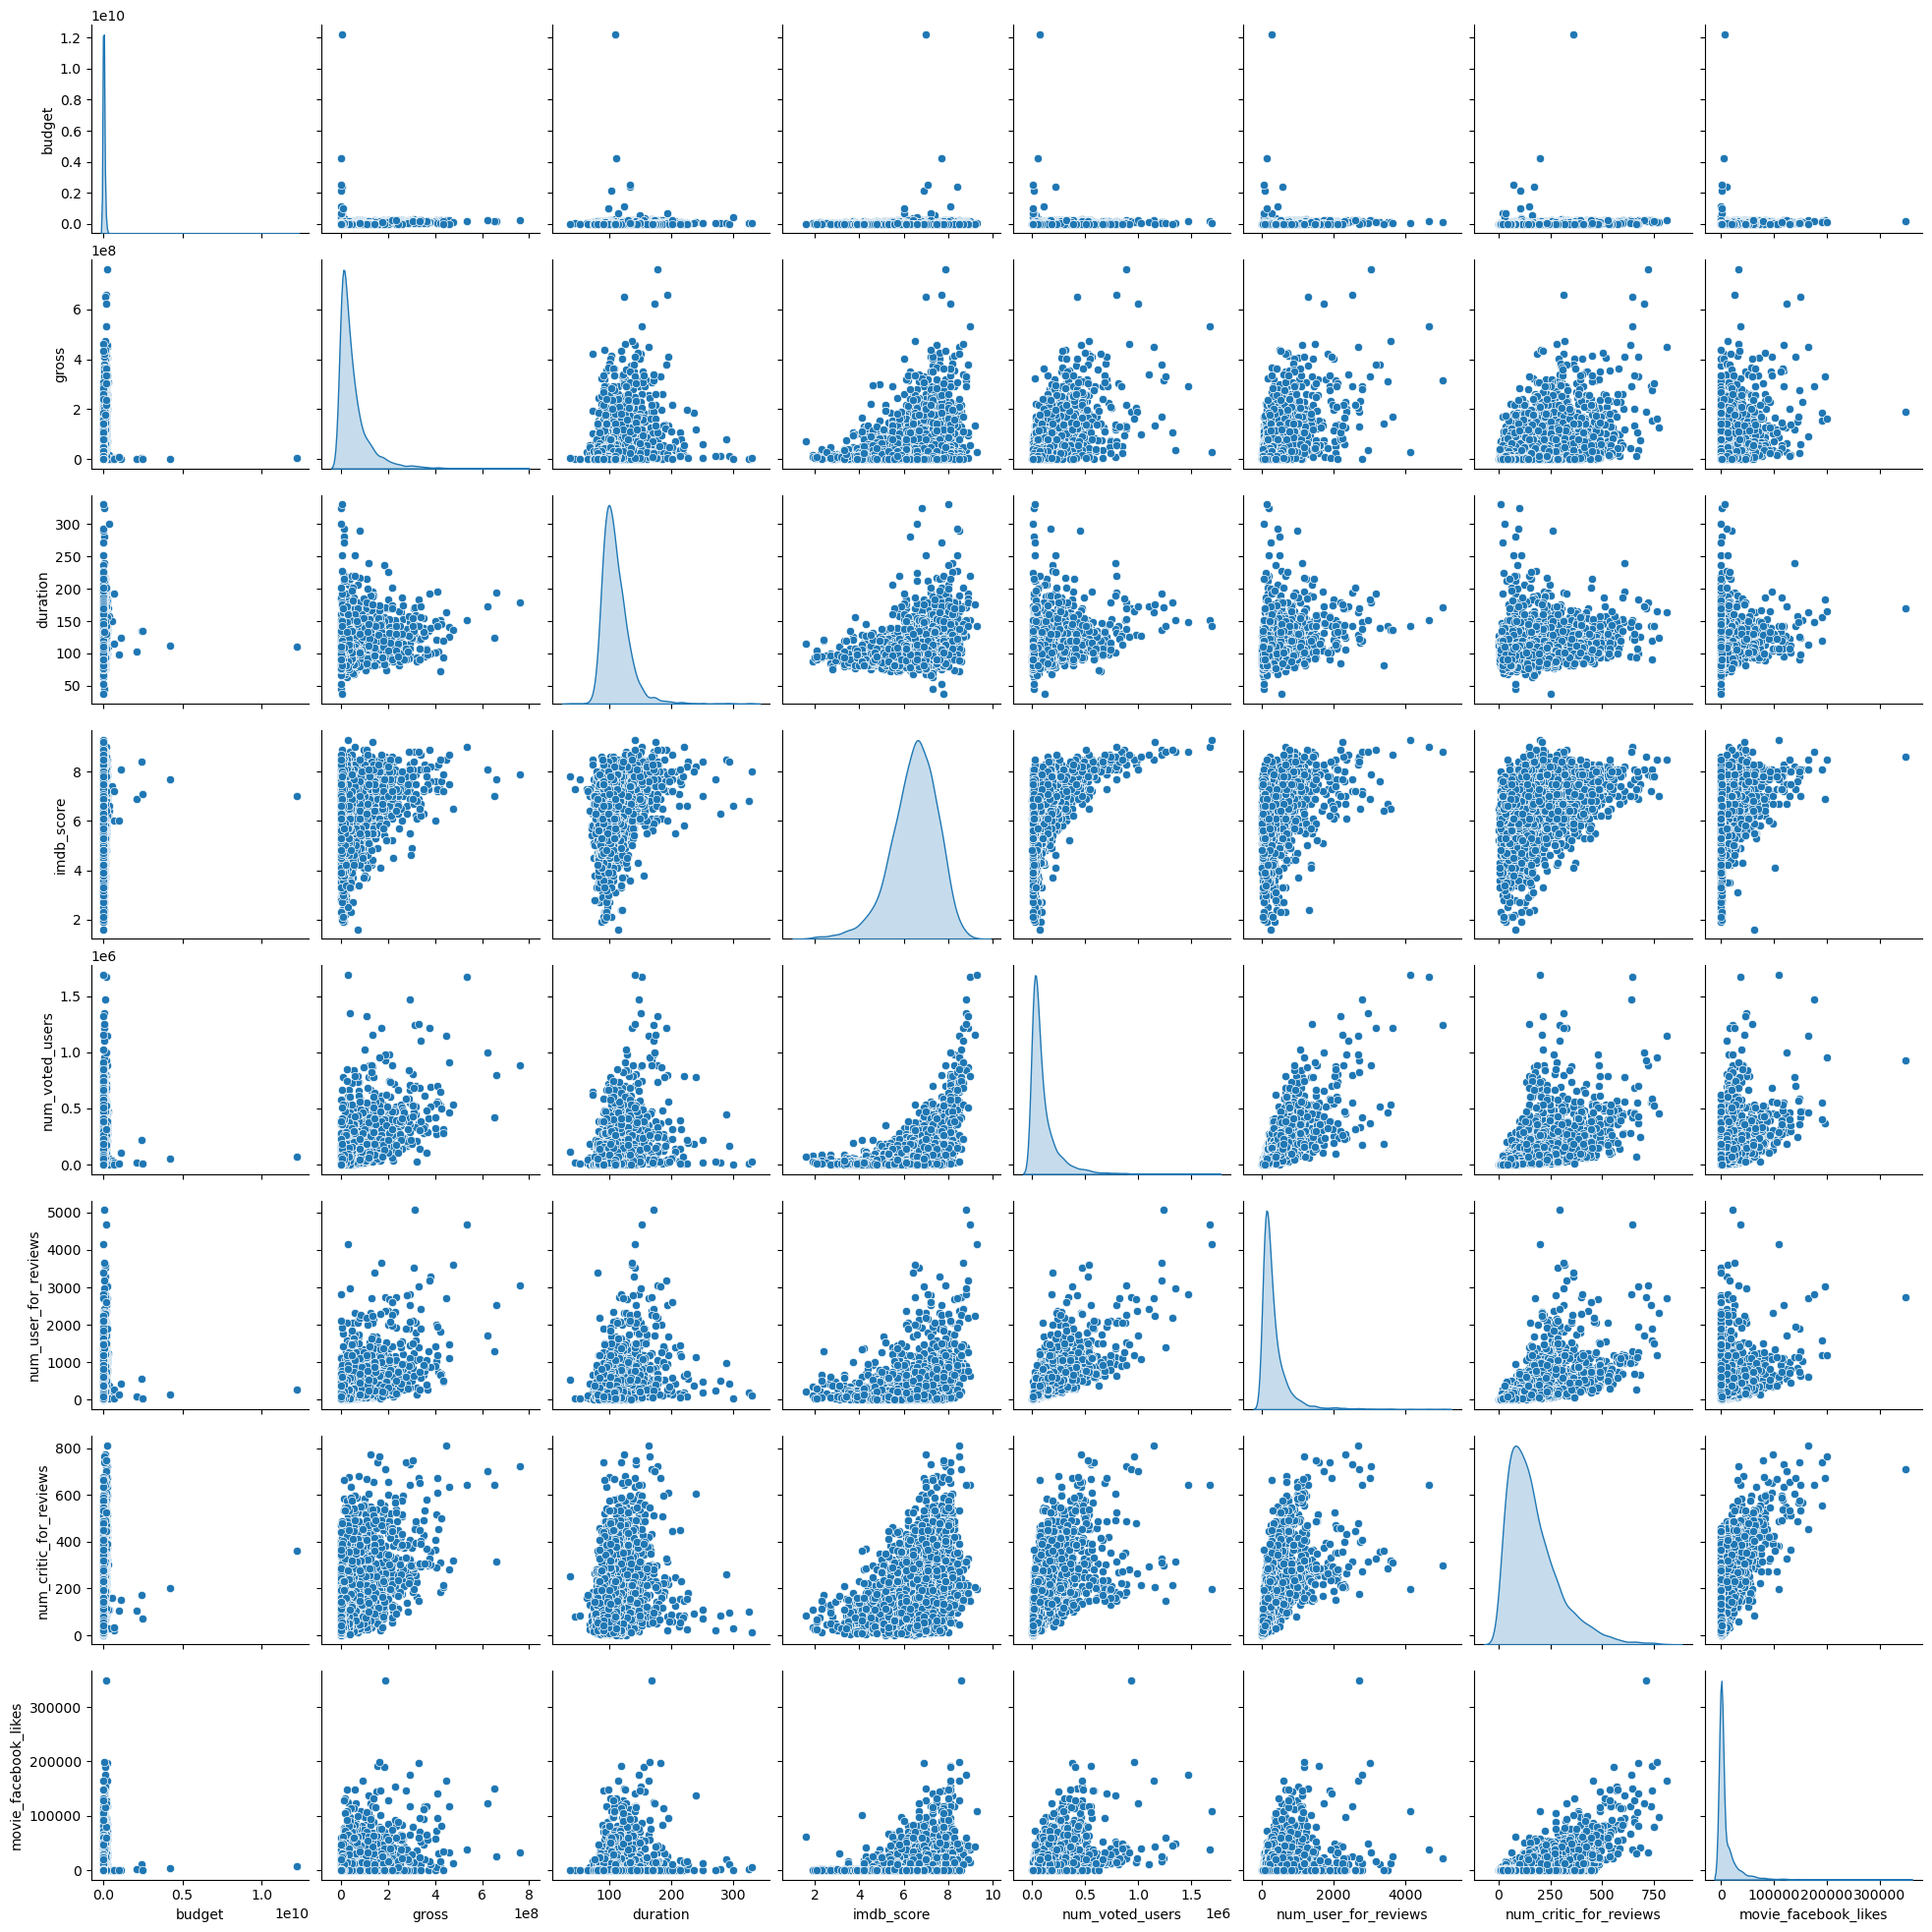

In [28]:
sns.pairplot(df[selected_columns], diag_kind="kde")
plt.show()


<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


### Top 10 highest grossing movies

C:\Users\Harshal\AppData\Local\Temp\ipykernel_27968\3058369982.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="gross", y="movie_title", data=top_grossing, palette="viridis")


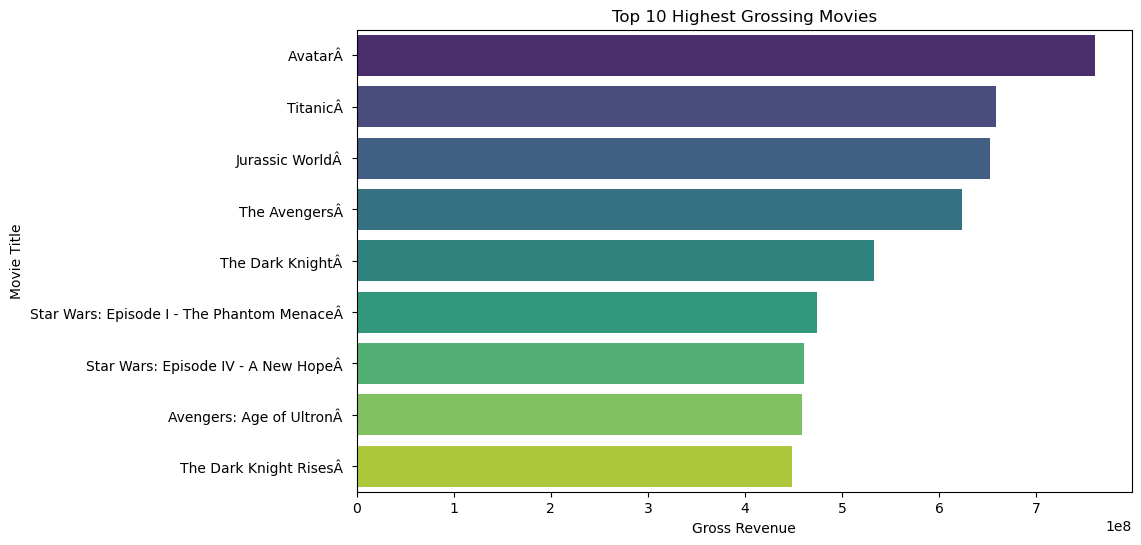

In [9]:
top_grossing = df.sort_values(by="gross", ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x="gross", y="movie_title", data=top_grossing, palette="viridis")
plt.title("Top 10 Highest Grossing Movies")
plt.xlabel("Gross Revenue")
plt.ylabel("Movie Title")
plt.show()

##### Avatar is the highest grossing movie

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


### Top 10 Best Rated Movies

C:\Users\Harshal\AppData\Local\Temp\ipykernel_27968\1055159788.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="imdb_score", y="movie_title", data=top_rated, palette="magma")


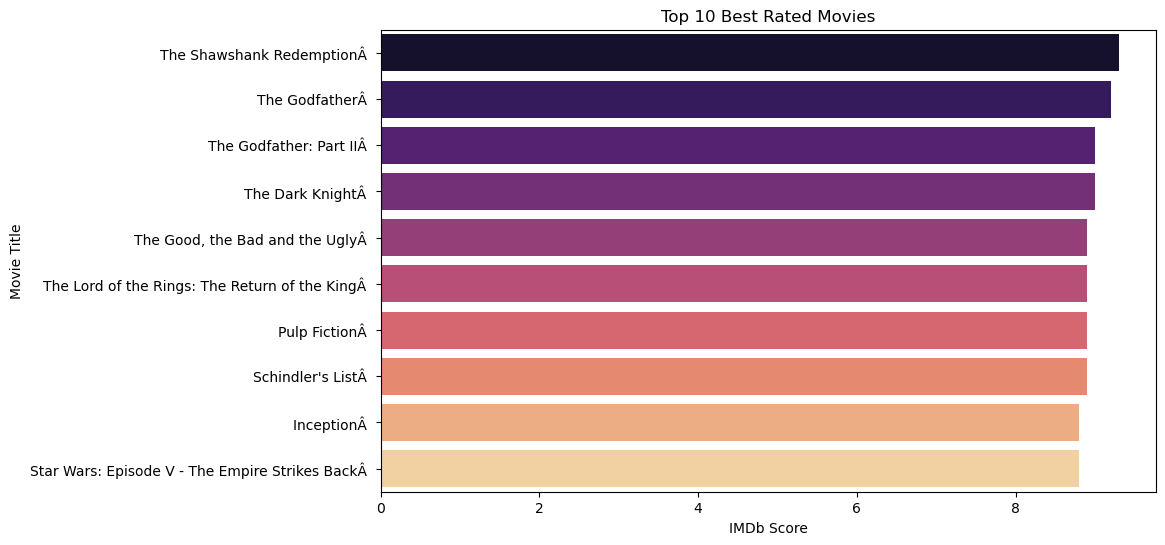

In [10]:
top_rated = df.sort_values(by="imdb_score", ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x="imdb_score", y="movie_title", data=top_rated, palette="magma")
plt.title("Top 10 Best Rated Movies")
plt.xlabel("IMDb Score")
plt.ylabel("Movie Title")
plt.show()


##### The best movie according to critics is shawshant redemption

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


### Budget distribution

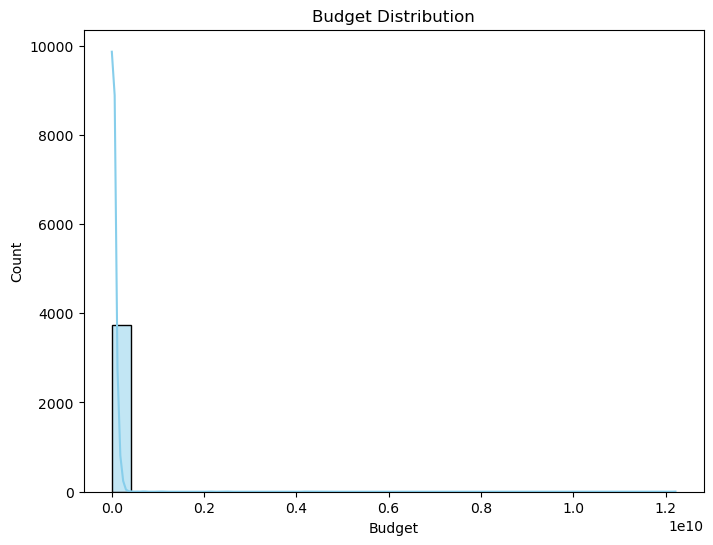

In [13]:
plt.figure(figsize=(8,6))
sns.histplot(df["budget"].dropna(), bins=30, kde=True, color="skyblue")
plt.title("Budget Distribution")
plt.xlabel("Budget")
plt.ylabel("Count")
plt.show()


##### Most of the movies have almost simillar budget

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


### Movie duration distribution

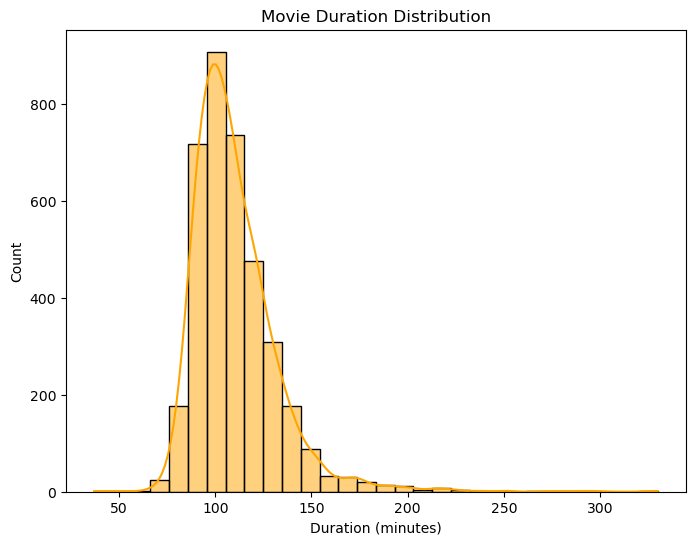

In [14]:
plt.figure(figsize=(8,6))
sns.histplot(df["duration"].dropna(), bins=30, kde=True, color="orange")
plt.title("Movie Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.show()


##### Most movies falls under 100 to 150 minutes with some outlires

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


### Languages distribution

C:\Users\Harshal\AppData\Local\Temp\ipykernel_27968\2076404746.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="language", data=df, order=df["language"].value_counts().head(10).index, palette="coolwarm")


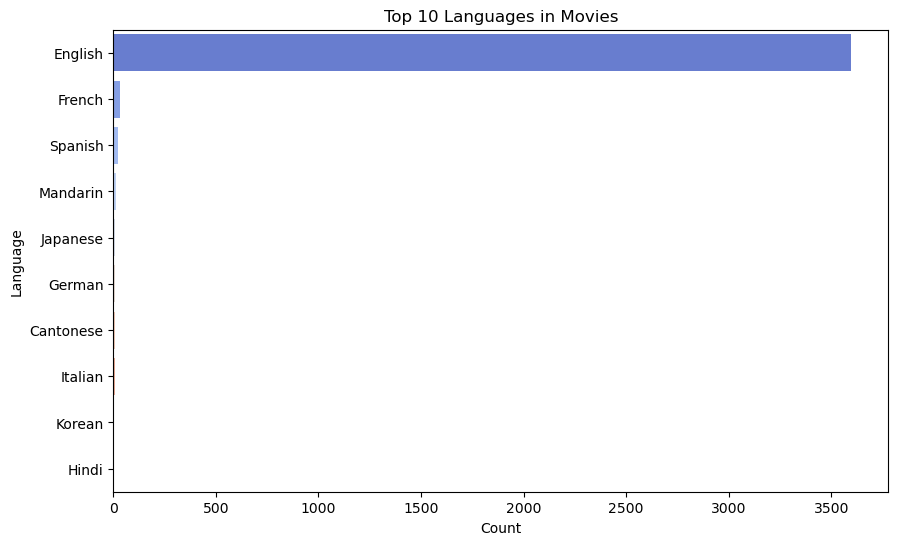

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(y="language", data=df, order=df["language"].value_counts().head(10).index, palette="coolwarm")
plt.title("Top 10 Languages in Movies")
plt.xlabel("Count")
plt.ylabel("Language")
plt.show()


##### 99% of the movies are english

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


### Country distribution

C:\Users\Harshal\AppData\Local\Temp\ipykernel_27968\1294791824.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["country"].value_counts().head(10).values,


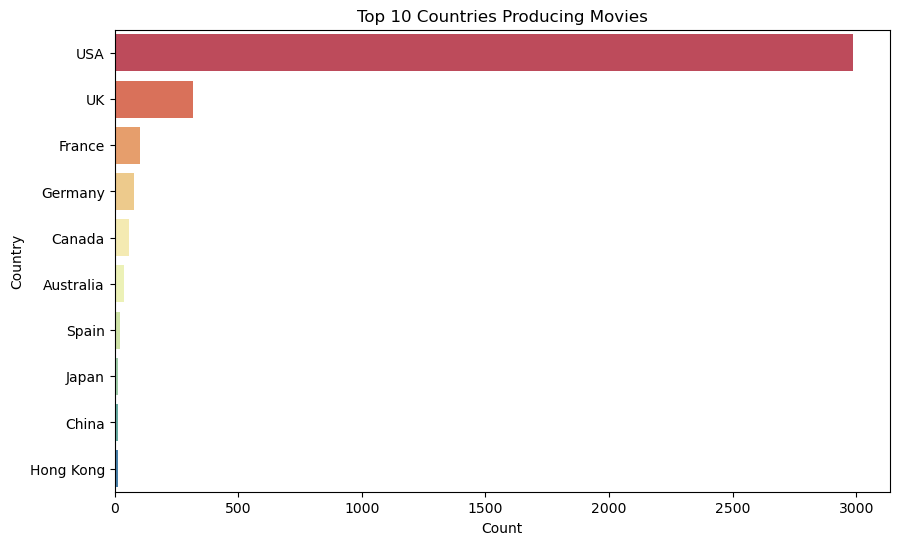

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(x=df["country"].value_counts().head(10).values,
            y=df["country"].value_counts().head(10).index,
            palette="Spectral")
plt.title("Top 10 Countries Producing Movies")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()


##### 90% of thwe movies are from USA

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


### Top directors

C:\Users\Harshal\AppData\Local\Temp\ipykernel_27968\2351858504.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["director_name"].value_counts().head(10).values,


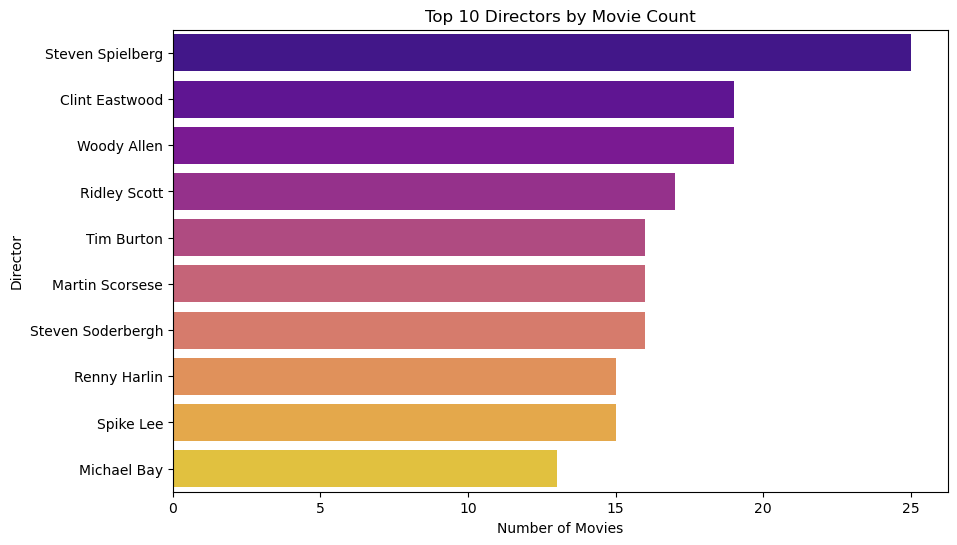

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(x=df["director_name"].value_counts().head(10).values,
            y=df["director_name"].value_counts().head(10).index,
            palette="plasma")
plt.title("Top 10 Directors by Movie Count")
plt.xlabel("Number of Movies")
plt.ylabel("Director")
plt.show()


##### Steven spielberg comes at the top

###### Key note: steven spielberg comes 2 times

<hr style="height:6px; border:none; background:linear-gradient(to right, orange 0%, orange 32%, white 32%, white 48%, blue 50%, white 52%, white 68%, green 68%, green 100%);">


#### Results
The heatmap shows that Gross revenue is most strongly correlated with Budget and num_voted_users, confirming that investment and audience size drive box office success. IMDb Score has moderate correlations with num_critic_for_reviews and num_voted_users, suggesting that both critical attention and popularity influence ratings.

Pairplots reinforce these findings:

Budget vs Gross: clear upward trend, with outliers where small films succeed and big ones flop.

Gross vs num_voted_users: strong linear relationship — popularity translates into revenue.

IMDb Score vs num_critic_for_reviews: clustering shows critically reviewed films tend to score higher.

Duration and movie_facebook_likes: weaker, indirect relationships.

Discussion
Overall, cinema success has two sides: financial performance depends on budget and reach, while quality perception is shaped by critics and audiences. Social media buzz and film length play minor roles. Outliers remind us that correlations show trends, but storytelling and timing can defy expectations.